# DQN Training Analysis
This notebook loads `results/dqn_summary.json`, visualizes training behavior, and compares DQN against the heuristic baselines.

In [12]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [13]:
RESULT_PATH = Path("../results/dqn_summary.json")

with open(RESULT_PATH, "r") as f:
    dqn_data = json.load(f)

train_df = pd.DataFrame(dqn_data["training_history"])
train_df.head()

,total_reward,average_queue_length,maximum_queue_length,throughput_per_step,total_departed,average_wait_time_steps,average_wait_time_seconds,switch_count,switch_requested_count,switch_applied_count,invalid_switch_count,episode,epsilon,mean_loss
0,-2282.0,10.930,22.0,3.220,644.0,3.358696,10.076087,48.0,48.0,48.0,0.0,0.0,0.990548,NaN
1,-2108.0,10.040,22.0,2.940,588.0,3.392857,10.178571,50.0,50.0,50.0,0.0,1.0,0.981047,NaN
2,-2146.0,10.210,21.0,3.075,615.0,3.304065,9.912195,52.0,52.0,52.0,0.0,2.0,0.971548,26.760644
3,-2559.0,12.305,30.0,3.180,636.0,3.729560,11.188679,49.0,49.0,49.0,0.0,3.0,0.962047,9.247552
4,-1953.0,9.255,20.0,2.980,596.0,3.075503,9.226510,51.0,51.0,51.0,0.0,4.0,0.952547,10.103425


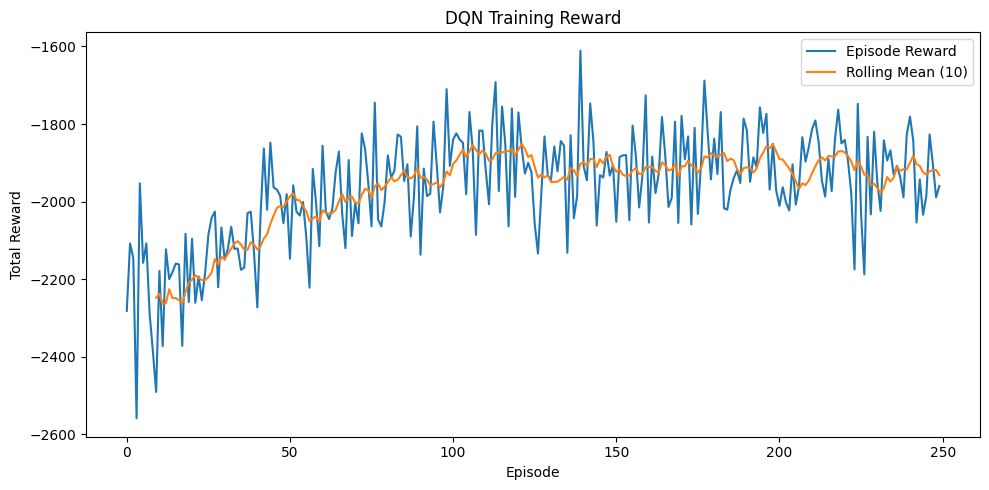

In [14]:
train_df["reward_rolling_10"] = train_df["total_reward"].rolling(10).mean()

plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["total_reward"], label="Episode Reward")
plt.plot(train_df["episode"], train_df["reward_rolling_10"], label="Rolling Mean (10)")
plt.title("DQN Training Reward")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.tight_layout()
plt.show()

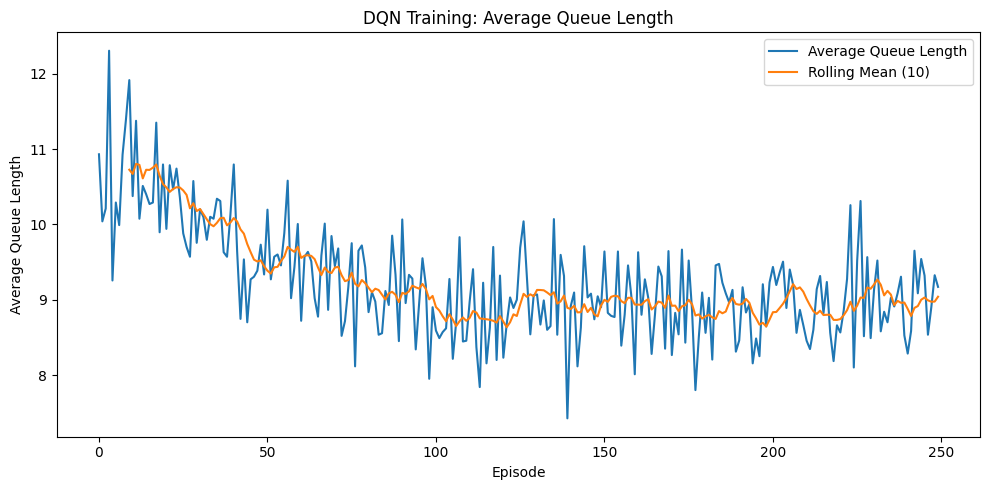

In [15]:
train_df["queue_rolling_10"] = train_df["average_queue_length"].rolling(10).mean()

plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["average_queue_length"], label="Average Queue Length")
plt.plot(train_df["episode"], train_df["queue_rolling_10"], label="Rolling Mean (10)")
plt.title("DQN Training: Average Queue Length")
plt.xlabel("Episode")
plt.ylabel("Average Queue Length")
plt.legend()
plt.tight_layout()
plt.show()

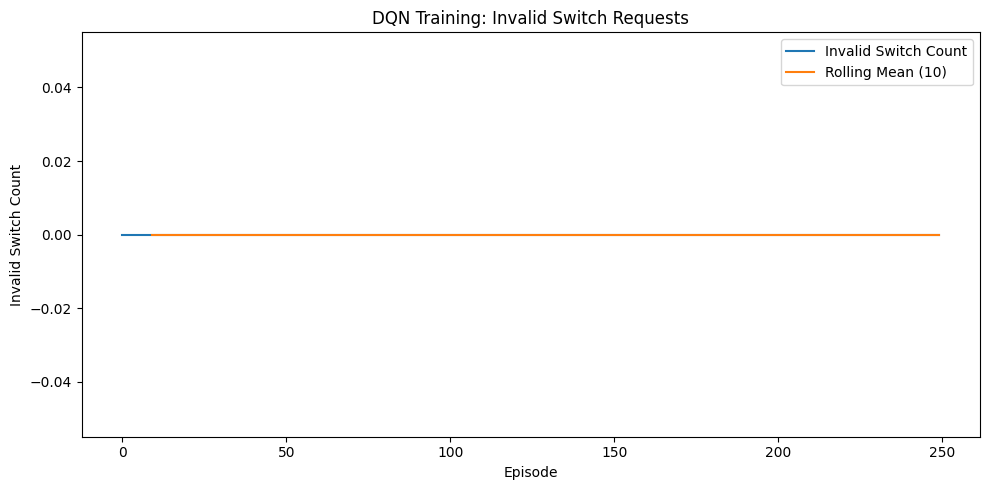

In [16]:
train_df["invalid_rolling_10"] = train_df["invalid_switch_count"].rolling(10).mean()

plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["invalid_switch_count"], label="Invalid Switch Count")
plt.plot(train_df["episode"], train_df["invalid_rolling_10"], label="Rolling Mean (10)")
plt.title("DQN Training: Invalid Switch Requests")
plt.xlabel("Episode")
plt.ylabel("Invalid Switch Count")
plt.legend()
plt.tight_layout()
plt.show()

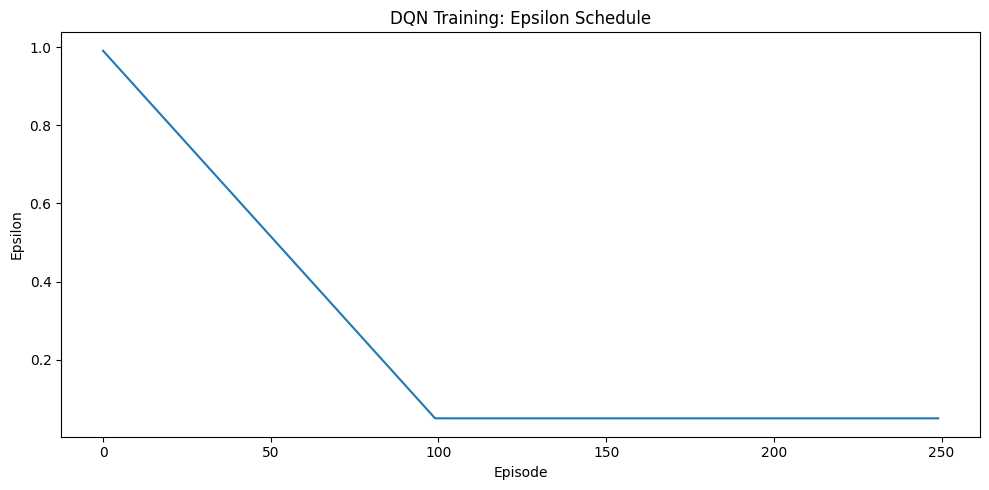

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(train_df["episode"], train_df["epsilon"])
plt.title("DQN Training: Epsilon Schedule")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.tight_layout()
plt.show()

In [18]:
eval_rows = []
for regime, policies in dqn_data["evaluation_results"].items():
    for policy, metrics in policies.items():
        row = {"regime": regime, "policy": policy}
        row.update(metrics)
        eval_rows.append(row)

eval_df = pd.DataFrame(eval_rows)
eval_df

,regime,policy,total_reward,average_queue_length,maximum_queue_length,throughput_per_step,total_departed,average_wait_time_steps,average_wait_time_seconds,switch_count,switch_requested_count,switch_applied_count,invalid_switch_count
0,symmetric_low,fixed_cycle,-1920.15,9.42075,22.30,1.95600,391.20,4.779091,14.337272,18.00,18.00,18.00,0.0
1,symmetric_low,queue_threshold,-1303.85,6.23175,14.50,1.95725,391.45,3.141217,9.423651,28.75,28.75,28.75,0.0
2,symmetric_low,max_pressure,-1130.00,5.03100,13.05,1.96350,392.70,2.539709,7.619127,61.90,61.90,61.90,0.0
3,symmetric_low,dqn,-1173.45,5.21425,13.25,1.95900,391.80,2.632010,7.896031,65.30,65.30,65.30,0.0
4,symmetric_high,fixed_cycle,-5349.50,26.56750,46.00,4.57900,915.80,5.662634,16.987901,18.00,18.00,18.00,0.0
5,symmetric_high,queue_threshold,-3501.70,17.04400,31.45,4.63900,927.80,3.612054,10.836162,46.45,46.45,46.45,0.0
6,symmetric_high,max_pressure,-4124.70,19.98650,35.90,4.61100,922.20,4.205359,12.616076,63.70,63.70,63.70,0.0
7,symmetric_high,dqn,-3302.25,15.96725,29.60,4.64325,928.65,3.383085,10.149254,54.40,54.40,54.40,0.0
8,asymmetric,fixed_cycle,-4269.55,21.16775,46.25,3.68200,736.40,5.698268,17.094805,18.00,18.00,18.00,0.0
9,asymmetric,queue_threshold,-2349.15,11.40875,25.55,3.68950,737.90,3.042580,9.127740,33.70,33.70,33.70,0.0


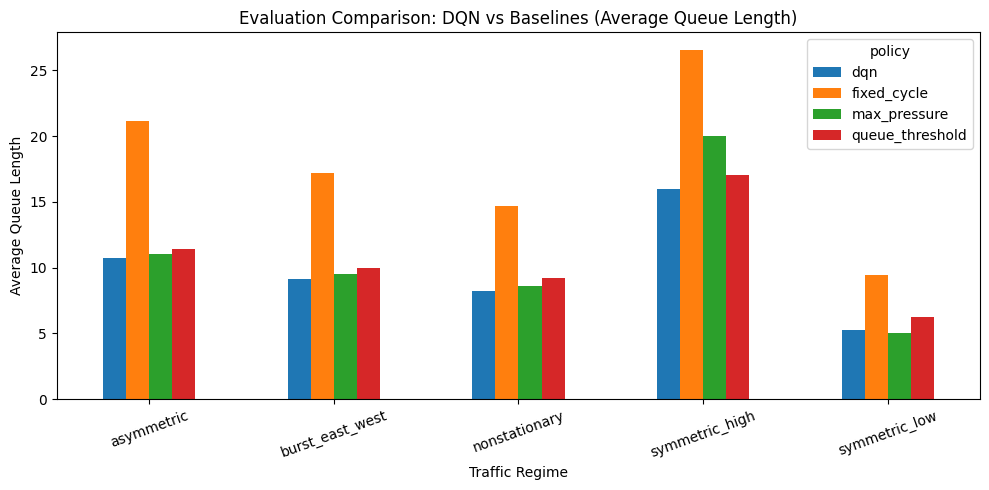

In [19]:
pivot_eval_queue = eval_df.pivot(index="regime", columns="policy", values="average_queue_length")
pivot_eval_queue.plot(kind="bar", figsize=(10, 5))
plt.title("Evaluation Comparison: DQN vs Baselines (Average Queue Length)")
plt.ylabel("Average Queue Length")
plt.xlabel("Traffic Regime")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

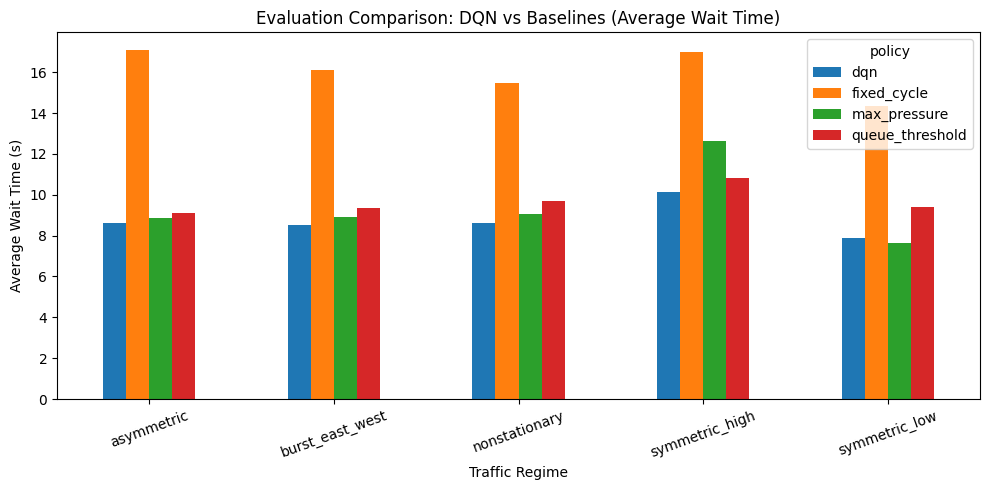

In [20]:
pivot_eval_wait = eval_df.pivot(index="regime", columns="policy", values="average_wait_time_seconds")
pivot_eval_wait.plot(kind="bar", figsize=(10, 5))
plt.title("Evaluation Comparison: DQN vs Baselines (Average Wait Time)")
plt.ylabel("Average Wait Time (s)")
plt.xlabel("Traffic Regime")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

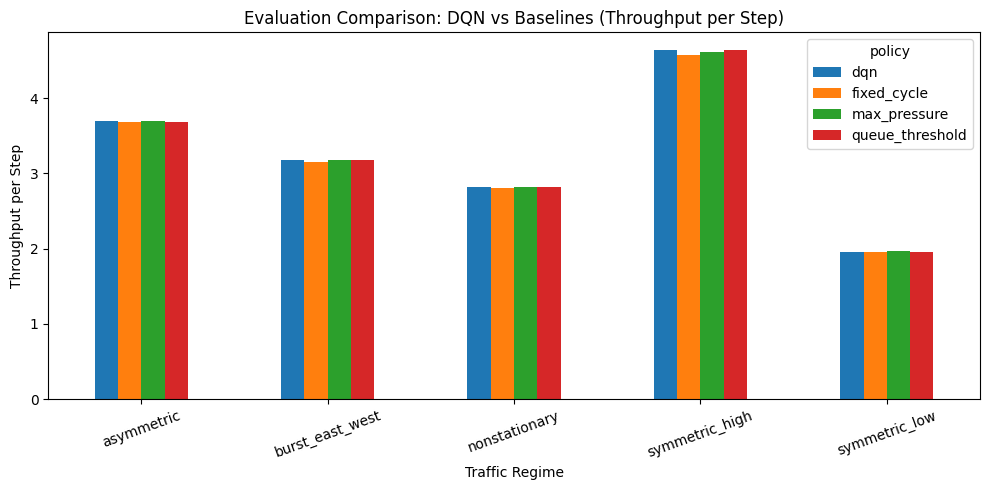

In [21]:
pivot_eval_throughput = eval_df.pivot(index="regime", columns="policy", values="throughput_per_step")
pivot_eval_throughput.plot(kind="bar", figsize=(10, 5))
plt.title("Evaluation Comparison: DQN vs Baselines (Throughput per Step)")
plt.ylabel("Throughput per Step")
plt.xlabel("Traffic Regime")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [22]:
baseline_only = eval_df[eval_df["policy"] != "dqn"].copy()
dqn_only = eval_df[eval_df["policy"] == "dqn"].copy()

best_baseline = baseline_only.loc[
    baseline_only.groupby("regime")["average_queue_length"].idxmin(),
    ["regime", "policy", "average_queue_length"]
].rename(columns={
    "policy": "best_baseline",
    "average_queue_length": "best_baseline_avg_queue"
})

dqn_queue = dqn_only[["regime", "average_queue_length"]].rename(columns={
    "average_queue_length": "dqn_avg_queue"
})

comparison = best_baseline.merge(dqn_queue, on="regime")
comparison["queue_improvement_pct"] = (
    (comparison["best_baseline_avg_queue"] - comparison["dqn_avg_queue"])
    / comparison["best_baseline_avg_queue"] * 100
)

display(comparison.sort_values("regime"))

,regime,best_baseline,best_baseline_avg_queue,dqn_avg_queue,queue_improvement_pct
0,asymmetric,max_pressure,11.0395,10.73775,2.733367
1,burst_east_west,max_pressure,9.5395,9.10650,4.539022
2,nonstationary,max_pressure,8.6260,8.19225,5.028403
3,symmetric_high,queue_threshold,17.0440,15.96725,6.317472
4,symmetric_low,max_pressure,5.0310,5.21425,-3.642417


## Current Key observations
- DQN outperforms the strongest heuristic baseline in 4 of 5 regimes on both average queue length and average wait time.
- DQN underperforms only slightly in the symmetric-low regime, where max-pressure remains marginally better.
- The learned policy appears especially effective under asymmetric, nonstationary, and bursty traffic conditions.
- Invalid switch counts are zero in evaluation, indicating that the legality-constrained action handling is working as intended.
- DQN improves congestion metrics, but not throughput; it also switches frequently, so the main benefit is lower queueing and waiting rather than universal dominance across all metrics.